In [1]:
import uproot
import matplotlib
import pandas as pd
import numpy as np
from tqdm import tqdm
import dask.dataframe as dd
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import glob
import boost_histogram as bh
import os
import re
from multihist import Histdd
from tqdm import tqdm
from utils import activity
import matplotlib.colors as mcolors

### Helper Functions

In [2]:
#############################
# Energy Resolution Function
#############################

# Function taken from from XENON1T 
def energy_res(energy, a_res=0.317, b_res=1.7):
    resolution = a_res*np.sqrt(energy)+b_res*10**-3*energy
    e_smeared = np.random.normal(energy,resolution)
    return e_smeared

In [3]:
#############################
# Activity/Isotope/Vol Dict
#############################
act_dict = activity

#############################
# Volume Mass Dict
#############################

mass_dict = {'PMT': 2368, 'Sapphire': 250, 'Teflon':300, 'Cryostat': 12900, 'Copper': 505}

In [4]:
# Assumed this number is tracked. Best to get info directly from files later.
num_primaries_perfile = {'PMT': 250000, 'Teflon': 250000, 'Cryostat': 250000, 'Sapphire': 250000, 'Copper': 250000}

In [5]:
#Combine Mass and Activity dicts to determine Scaling Factors
scale_dict = {}
for vol_key, volume in act_dict.items():
    volume_scale = {}
    for iso_key, isotope in volume.items():
        if iso_key == 'Unit':
            continue
        elif not isinstance(act_dict[vol_key][iso_key], str):
            if (act_dict[vol_key][iso_key])>0:
                scale_factor = num_primaries_perfile[vol_key]/(mass_dict[vol_key]*act_dict[vol_key][iso_key]*1e-3)
            else:
                scale_factor=0
        volume_scale[iso_key] = scale_factor
        #print(scale_factor)
    scale_dict[vol_key] = volume_scale

In [6]:
#############################
# Selection Functions
#############################
def select_ss_ms_events(df):
    # For each runid, for each eventid, select clusters with only one cluster_id (single scatter)
    ss_events = df[df['nclusters'] == 1]
    ms_events = df[df['nclusters'] > 1]
    
    return ss_events, ms_events

def select_events_in_energy_range(df, energy_range=(4, 50)):
    # energy ROI cut
    # NR: (4, 50) keV -> ER: (1, 12) keV
    return df[df["edep"].between(*energy_range)]

# and occur inside the fiducial volume and within the energy ROI
def select_events_in_roi(df, fv_z, fv_radius, energy_range=(4, 50)):
    # Apply fiducial volume cut
    events_fv = df[df["zp"].between(*fv_z) & (df["xp"]**2 + df["yp"]**2 <= fv_radius**2)]
    events_roi = select_events_in_energy_range(events_fv, energy_range=energy_range)
    return events_roi

### Raw Distributions

In [83]:
file_prefix = ''
fv_x = 500  # mm
fv_z = (-800, 800)  # mm
max_index=100

for isotope in ['U238', 'Th232', 'Co60']:
    for key, volume in act_dict.items():
        all_dfs = []
    
        # Search for all files matching the pattern for this key + isotope
        file_pattern = f'/storage/xenon/nadavh/hermeticTPC/BigStats_01/{key}/{isotope}/{key}_{isotope}_*_s10mm.parquet'
        matched_files_n = sorted(glob.glob(file_pattern))
        file_pattern = f'/storage/xenon/jacquesp/hermeticTPC/BigStats_01/{key}/{isotope}/{key}_{isotope}_*_s10mm.parquet'
        matched_files_j = sorted(glob.glob(file_pattern))
        matched_files = np.concatenate([matched_files_j,matched_files_n])
        
        for filepath in tqdm(matched_files):
            filename = os.path.basename(filepath)
    
            # Use regex to extract serial number (handles zero-padding)
            match = re.match(rf'{re.escape(file_prefix)}{re.escape(key)}_{re.escape(isotope)}_(\d+)\_s10mm.parquet', filename)
            if match:
                serial_num = int(match.group(1))
                if serial_num > max_index:
                    continue
    
                # Load and collect DataFrame
                try:
                    iso_vol_df = pd.read_parquet(filepath)

                    #Find Single Scatters
                    iso_vol_df = iso_vol_df[iso_vol_df['nclusters']==1]
                    all_dfs.append(iso_vol_df)
                except:
                    continue
                
            else:
                print(f"Skipping file (name format doesn't match): {filename}")
    
        # Concatenate all matching DataFrames
        if not all_dfs:
            print(f"No files found for key {key}, isotope {isotope}")
            continue

        file_loaded_counter = len(all_dfs)
        fuse_data = pd.concat(all_dfs, ignore_index=True)
    
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

    hxy = ax1.hist2d(fuse_data["xp"], fuse_data["yp"], bins=150, norm=matplotlib.colors.LogNorm())
    ax1.set_title(f"Scatters for {isotope}")
    ax1.set_xlabel("x (mm)")
    ax1.set_ylabel("y (mm)")
    ax1.set_aspect('equal', adjustable='box')

    hyz = ax2.hist2d(fuse_data["yp"], fuse_data["zp"], bins=150, norm=matplotlib.colors.LogNorm())
    #ax2.set_title(f"Fuse Cluster for {key}")
    ax2.set_xlabel("y (mm)")
    ax2.set_ylabel("z (mm)")
    #ax2.set_aspect('equal', adjustable='box')

    # make a box for the fiducial volume
    ax1.add_patch(plt.Circle((0, 0), fv_x, color='red', fill=False, linestyle='--', linewidth=2, label='Fiducial Volume'))
    ax2.add_patch(plt.Rectangle((-fv_x, fv_z[0]), 2*fv_x, 2*fv_z[1], color='red', fill=False, linestyle='--', linewidth=2))

    fig.colorbar(hxy[3], label="Counts")
    fig.colorbar(hyz[3], label="Counts")
    fig.tight_layout()
    plt.show()


    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

    hxy = ax1.hist2d(fuse_data["xp_pri"], fuse_data["yp_pri"], bins=150, norm=matplotlib.colors.LogNorm())
    ax1.set_title(f"Primaries for {isotope}")
    ax1.set_xlabel("x_pri (mm)")
    ax1.set_ylabel("y_pri (mm)")
    ax1.set_aspect('equal', adjustable='box')

    hyz = ax2.hist2d(fuse_data["yp_pri"], fuse_data["zp_pri"], bins=150, norm=matplotlib.colors.LogNorm())
    #ax2.set_title(f"Fuse Cluster for {key}")
    ax2.set_xlabel("y_pri (mm)")
    ax2.set_ylabel("z_pri (mm)")
    #ax2.set_aspect('equal', adjustable='box')

    fig.colorbar(hxy[3], label="Counts")
    fig.colorbar(hyz[3], label="Counts")
    fig.tight_layout()

    plt.show()


    fig = plt.figure(figsize=(14,5))
    plt.hist(energy_res(fuse_data["edep"], 0.317, 1.7), bins=100, histtype='step', label='All clusters')

    data_fv = energy_res(fuse_data[fuse_data["zp"].between(*fv_z) & (fuse_data["xp"]**2 + fuse_data["yp"]**2 <= fv_x**2)]["edep"], 0.317, 1.7)
    print(len(data_fv))
    plt.hist(data_fv, bins=100, histtype='step', label='FV clusters', color='red')

    plt.legend()

    plt.xlabel("Energy deposition (keV)")
    plt.ylabel("Counts")
    plt.yscale("log")

    plt.show()

  0%|▎                                                                                | 19/4394 [00:07<27:58,  2.61it/s]


KeyboardInterrupt: 

### Rate Plots

In [7]:
LXe = {
    "density": 2.862, # g/cm3
    "temperature": 177.05, # K
    "pressure": 1.5 # bar
}

TPC_dimensions = {
    "radius": 1500, # mm
    "top": 1365, # mm
    "bottom": -1682, # mm
}
TPC_center = [0, 0, TPC_dimensions["top"]-(TPC_dimensions["top"] - TPC_dimensions["bottom"]) / 2]

In [ ]:
file_prefix = ''

#Max Files
max_index=5000

#Scaling Settings
year = 3.154e7  #seconds
estimates = {}
fv_radius = TPC_dimensions['radius']
fv_z = [TPC_dimensions['bottom'], TPC_dimensions['top']]
height =(fv_z[1]-fv_z[0])
volume = height/10*np.pi*(fv_radius/10)**2
fv_mass = (volume*LXe['density'])/1e6
_erange = (2000, 3000)

energy_binning = np.linspace(2000, 3000, 101)
for isotope in ['U238', 'Th232', 'Co60']:#, 'K40', 'Cs137']:
    background_hist = Histdd(bins=[energy_binning])
    binwidth = background_hist.bin_centers(0)[1]-background_hist.bin_centers(0)[0]
    errors=np.zeros_like(background_hist.bin_centers(0))
    for key, volume in act_dict.items():
        all_dfs = []
    
        # Search for all files matching the pattern for this key + isotope
        #file_pattern = f'/storage/xenon/jacquesp/hermeticTPC/{key}_{isotope}_*.parquet'
        file_pattern = f'/storage/xenon/nadavh/hermeticTPC/BigStats_01/{key}/{isotope}/{key}_{isotope}_*_s10mm.parquet'
        matched_files_n = sorted(glob.glob(file_pattern))
        file_pattern = f'/storage/xenon/jacquesp/hermeticTPC/BigStats_01/{key}/{isotope}/{key}_{isotope}_*_s10mm.parquet'
        matched_files_j = sorted(glob.glob(file_pattern))
        matched_files = np.concatenate([matched_files_j,matched_files_n])
        
        for filepath in tqdm(matched_files):
            filename = os.path.basename(filepath)
    
            # Use regex to extract serial number (handles zero-padding)
            match = re.match(rf'{re.escape(file_prefix)}{re.escape(key)}_{re.escape(isotope)}_(\d+)\_s10mm.parquet', filename)
            if match:
                serial_num = int(match.group(1))
                if serial_num > max_index:
                    continue
    
                # Load and collect DataFrame
                try:
                    iso_vol_df = pd.read_parquet(filepath)

                    #Find Single Scatters
                    iso_vol_df = iso_vol_df[iso_vol_df['nclusters']==1]
                    all_dfs.append(iso_vol_df)
                except:
                    continue
                
            else:
                print(f"Skipping file (name format doesn't match): {filename}")
    
        # Concatenate all matching DataFrames
        if not all_dfs:
            print(f"No files found for key {key}, isotope {isotope}")
            continue
            
        file_loaded_counter = len(all_dfs)
        fuse_data = pd.concat(all_dfs, ignore_index=True)

        df_ss, df_ms = select_ss_ms_events(fuse_data)
        df_ss_energy = select_events_in_energy_range(df_ss, energy_range=(_erange))
        df_ss_roi = select_events_in_roi(df_ss_energy, fv_z, fv_radius, energy_range=(_erange))

        # Number of single scatter events total and in ROI
        e_ss_events = len(df_ss)
        e_ss_energy_events = len(df_ss_energy)
        e_ss_roi_events = len(df_ss_roi)

        # Scaling factor
        try:
            scale_factor = year / (scale_dict[key][isotope]* file_loaded_counter)
        except:
            print(isotope, key, scale_dict[key][isotope], file_loaded_counter, fv_mass)
            
        # Store histograms
        h_xy_ss = bh.Histogram(bh.axis.Regular(200, -1500, 1500), bh.axis.Regular(200, -1500, 1500))
        h_xy_ss.fill(df_ss["xp"], df_ss["yp"])
       
        h_rz_ss = bh.Histogram(bh.axis.Regular(200, 0, 1500), bh.axis.Regular(200, -1800, 1500))
        h_rz_ss.fill(np.sqrt(df_ss["xp"]**2 + df_ss["yp"]**2), df_ss["zp"])
        
        #Test 3D Histogram
        h_xy_ss_e = bh.Histogram(bh.axis.Regular(200, -1500, 1500), 
                                 bh.axis.Regular(200, -1500, 1500), 
                                 bh.axis.Regular(100, *_erange))
        h_xy_ss_e.fill(df_ss_energy["xp"], 
                       df_ss_energy["yp"], 
                       energy_res(df_ss_energy["edep"], 0.317, 1.7))
        
        h_rz_ss_e = bh.Histogram(bh.axis.Regular(200, 0, 1500), 
                                 bh.axis.Regular(200, -1800, 1500), 
                                 bh.axis.Regular(100, *_erange))
        h_rz_ss_e.fill(np.sqrt(df_ss_energy["xp"]**2 + df_ss_energy["yp"]**2), 
                       df_ss_energy["zp"], 
                       energy_res(df_ss_energy["edep"], 0.317, 1.7))

        _estimates = {key: {
            "scale_factor": scale_factor,
            "e_ss_events": e_ss_events,
            "e_ss_energy_events": e_ss_energy_events,
            "e_ss_roi_events": e_ss_roi_events,
            "h_xy_ss": h_xy_ss,
             #"h_xy_ss_energy": h_xy_ss_energy,
            #"h_xy_ss_roi": h_xy_ss_roi,
            "h_rz_ss": h_rz_ss,
            #"h_rz_ss_energy": h_rz_ss_energy,
            #"h_rz_ss_roi": h_rz_ss_roi,
            "h_rz_ss_e": h_rz_ss_e,
            "h_xy_ss_e": h_xy_ss_e,
        }}
        if isotope not in estimates:
            estimates[isotope] = {}
        estimates[isotope].update(_estimates)

 18%|██████████████▍                                                                 | 790/4394 [08:38<26:46,  2.24it/s]

In [11]:
for material, mat_data in estimates.items():
    for isotope, iso_data in mat_data.items():
        print(f"Material: {material}, Isotope: {isotope}")
        print(f"  Total single scatter events: {iso_data['e_ss_events']}")
        print(f"  -> in energy ROI: {iso_data['e_ss_energy_events']}")
        print()

Material: U238, Isotope: PMT
  Total single scatter events: 235564594
  -> in energy ROI: 1683491

Material: U238, Isotope: Cryostat
  Total single scatter events: 10209417
  -> in energy ROI: 96656

Material: U238, Isotope: Teflon
  Total single scatter events: 36197609
  -> in energy ROI: 202528

Material: U238, Isotope: Copper
  Total single scatter events: 3229374
  -> in energy ROI: 22271

Material: U238, Isotope: Sapphire
  Total single scatter events: 140477458
  -> in energy ROI: 733910

Material: Th232, Isotope: PMT
  Total single scatter events: 103881189
  -> in energy ROI: 1420207

Material: Th232, Isotope: Cryostat
  Total single scatter events: 11818529
  -> in energy ROI: 415295

Material: Th232, Isotope: Teflon
  Total single scatter events: 22689392
  -> in energy ROI: 145261

Material: Th232, Isotope: Copper
  Total single scatter events: 5997314
  -> in energy ROI: 68259

Material: Th232, Isotope: Sapphire
  Total single scatter events: 42922778
  -> in energy ROI: 1

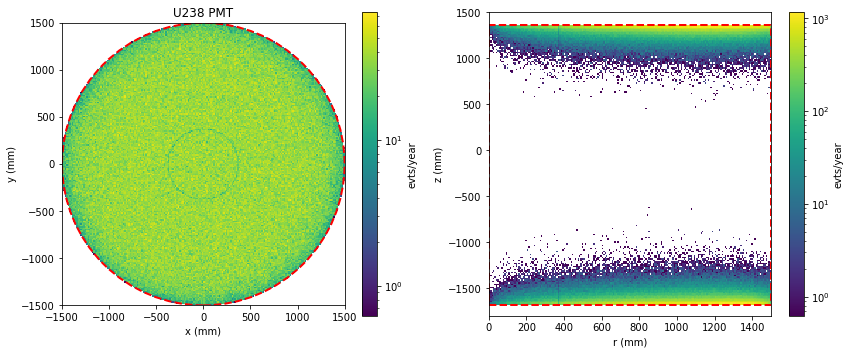

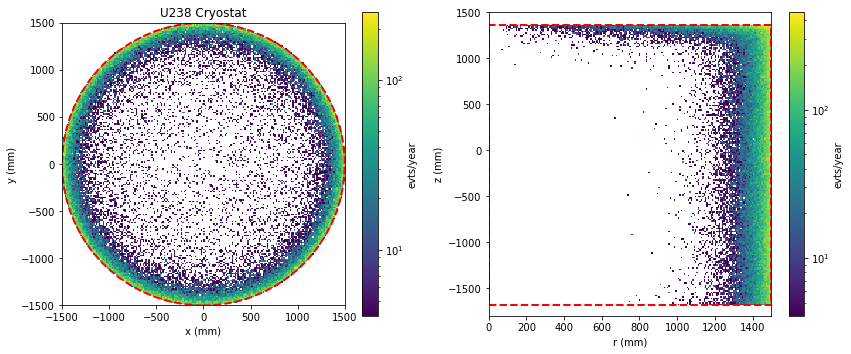

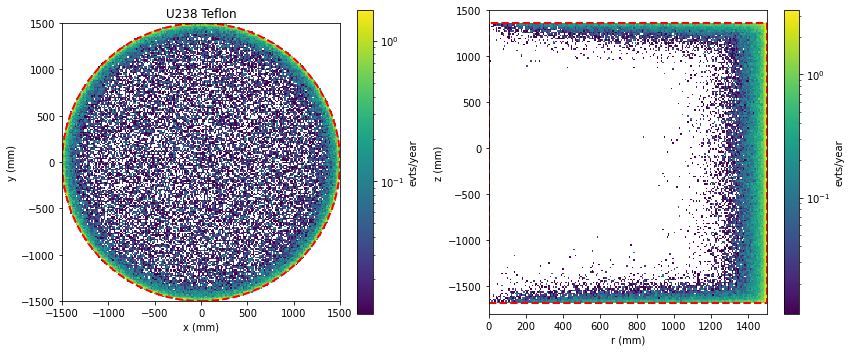

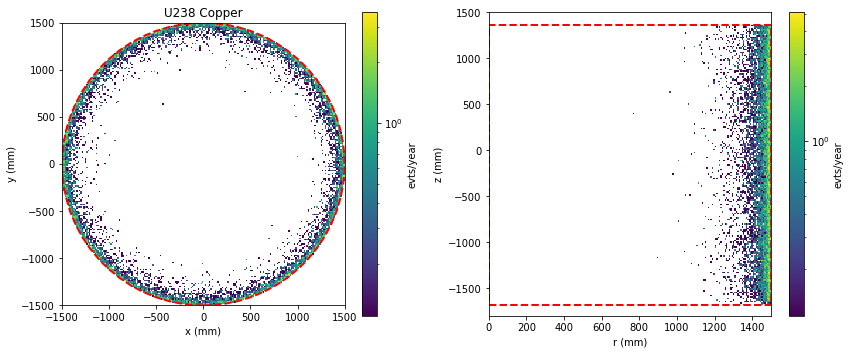

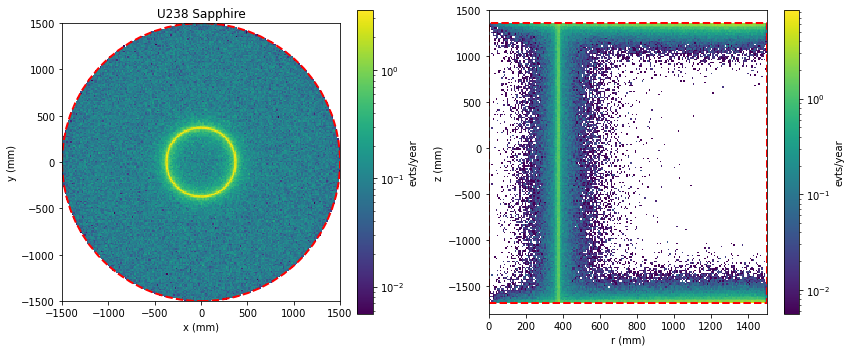

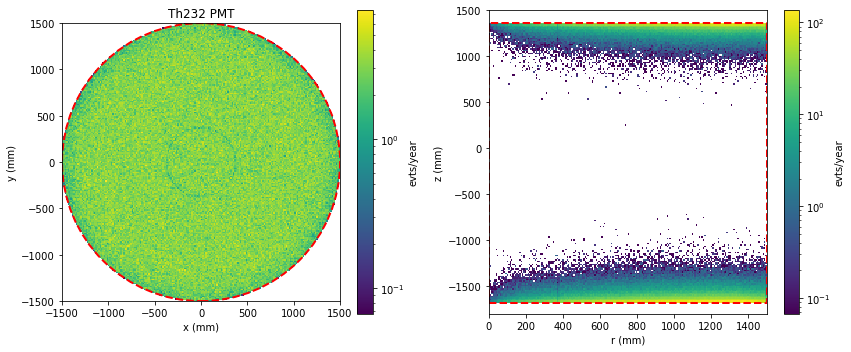

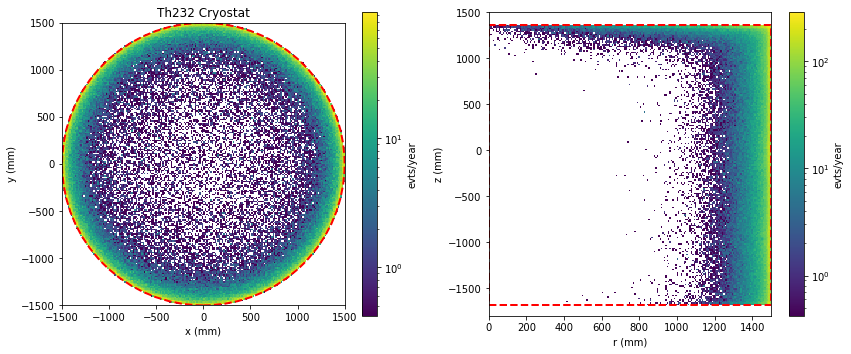

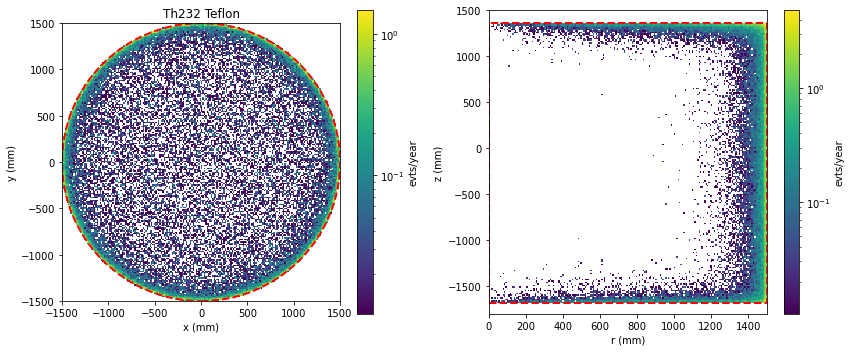

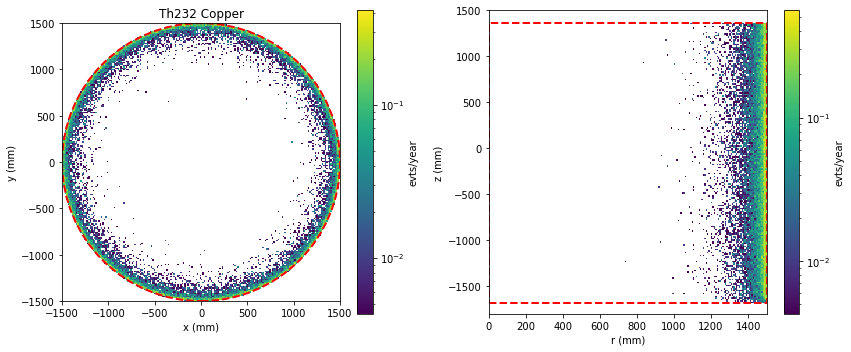

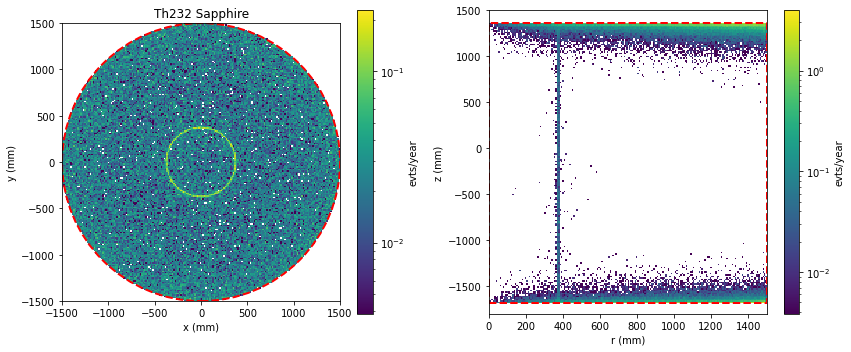

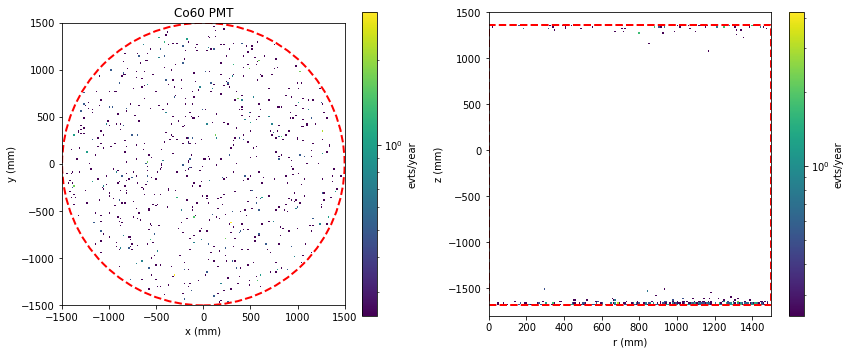

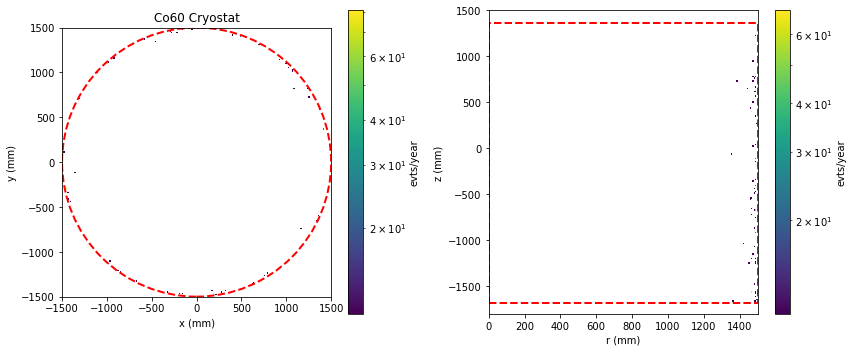

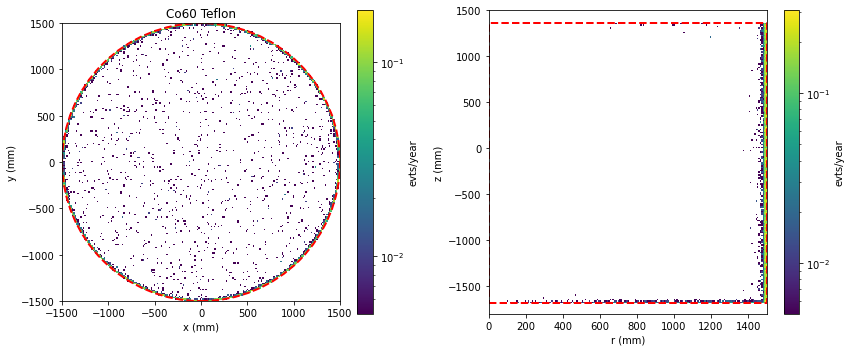

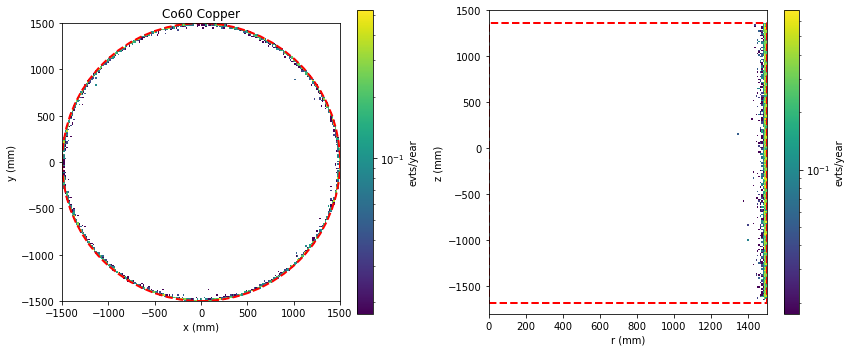

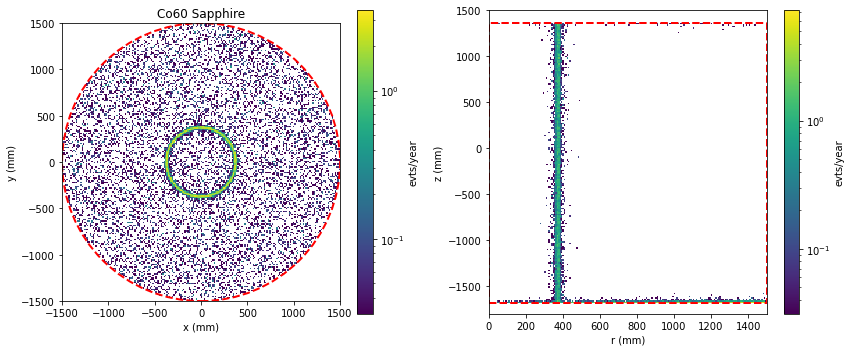

In [12]:
for material, mat_data in estimates.items():
    for isotope, iso_data in mat_data.items():
        try:
            fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
            
            h_xy = iso_data["h_xy_ss_e"].project(0, 1)
            h_rz = iso_data["h_rz_ss_e"].project(0, 1)
            
            vals_xy = h_xy.values().T * iso_data["scale_factor"]
            vals_rz = h_rz.values().T * iso_data["scale_factor"]

            vals_xy = np.where(vals_xy > 0, vals_xy, np.nan)
            vals_rz = np.where(vals_rz > 0, vals_rz, np.nan)

            pcm1 = ax1.pcolormesh(
                *h_xy.axes.edges.T,
                vals_xy,
                norm=matplotlib.colors.LogNorm()
                )
            ax1.add_patch(plt.Circle((0, 0), fv_radius, color='red', fill=False, linestyle='--', linewidth=2, label='Fiducial Volume'))

            ax1.set_title(f"{material} {isotope}")
            ax1.set_xlabel("x (mm)")
            ax1.set_ylabel("y (mm)")
            ax1.set_aspect('equal', adjustable='box')

            pcm2 = ax2.pcolormesh(
                *h_rz.axes.edges.T,
                vals_rz,
                norm=matplotlib.colors.LogNorm()
            )
            ax2.add_patch(plt.Rectangle((-0, fv_z[0]), fv_radius, fv_z[1]-fv_z[0], color='red', fill=False, linestyle='--', linewidth=2))

            ax2.set_xlabel("r (mm)")
            ax2.set_ylabel("z (mm)")

            plt.colorbar(pcm1, label="evts/year")
            plt.colorbar(pcm2, label="evts/year")
            fig.tight_layout()
            plt.show()
        except ValueError:
            plt.close(fig)
            print (f" Exception for {material}  {isotope}")
            continue

### Sum All Histograms

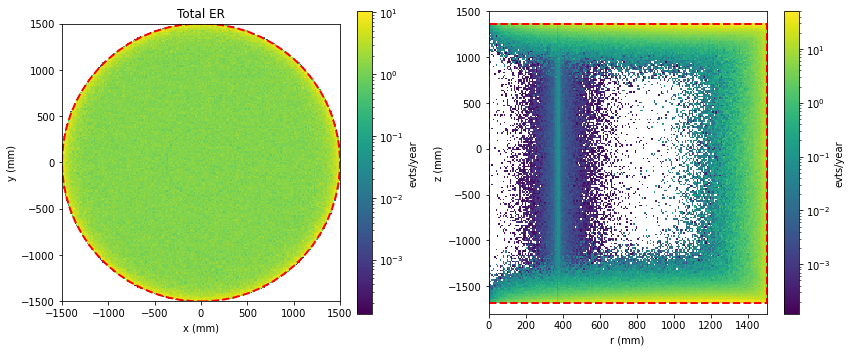

In [13]:
#del h_xy_total
#del h_rz_total
for material, mat_data in estimates.items():
    for isotope, iso_data in mat_data.items():
        try:
            h_xy_total
        except NameError:
            h_xy_total = iso_data["h_xy_ss_e"].copy()
            h_xy_total.reset()
        try:
            h_rz_total
        except:
            h_rz_total = iso_data["h_rz_ss_e"].copy()
            h_rz_total.reset()
        
        h_xy_total += iso_data["h_xy_ss_e"]*iso_data['scale_factor']
        h_rz_total += iso_data["h_rz_ss_e"]*iso_data['scale_factor']

h_xy = h_xy_total.project(0, 1)
h_rz = h_rz_total.project(0, 1)

vals_xy = h_xy.values().T * iso_data["scale_factor"]
vals_rz = h_rz.values().T * iso_data["scale_factor"]

vals_xy = np.where(vals_xy > 0, vals_xy, np.nan)
vals_rz = np.where(vals_rz > 0, vals_rz, np.nan)        
        
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

pcm1 = ax1.pcolormesh(
    *h_xy.axes.edges.T,
    vals_xy,
    norm=matplotlib.colors.LogNorm()
)
ax1.add_patch(plt.Circle((0, 0), fv_radius, color='red', fill=False, linestyle='--', linewidth=2, label='Fiducial Volume'))

ax1.set_title("Total ER")
ax1.set_xlabel("x (mm)")
ax1.set_ylabel("y (mm)")
ax1.set_aspect('equal', adjustable='box')

pcm2 = ax2.pcolormesh(
    *h_rz.axes.edges.T,
    vals_rz,
    norm=matplotlib.colors.LogNorm()
)
ax2.add_patch(plt.Rectangle((-0, fv_z[0]), fv_radius, fv_z[1]-fv_z[0], color='red', fill=False, linestyle='--', linewidth=2))

ax2.set_xlabel("r (mm)")
ax2.set_ylabel("z (mm)")

plt.colorbar(pcm1, label="evts/year")
plt.colorbar(pcm2, label="evts/year")
fig.tight_layout()
plt.show()

### Mass Volume Normalization histogram

In [14]:
h_vol = h_rz.copy()
h_vol.reset()

r_edges = h_rz.axes[0].edges
z_edges = h_rz.axes[1].edges

dr2 = np.diff(r_edges**2)  
dz  = np.diff(z_edges)    
volumes = np.pi * dr2[:, np.newaxis] * dz

h_vol.view()[:] = volumes*LXe['density']/1e9 #(1e6  to convert to tonne)

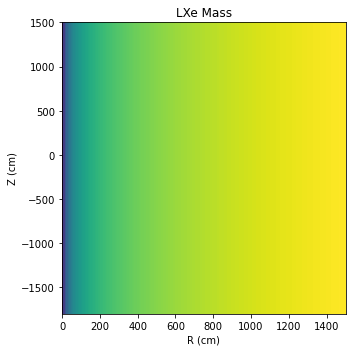

In [15]:
### To Do: Set Sapphire Bins to 0 mass
fig, (ax2) = plt.subplots(nrows=1, ncols=1, figsize=(5,5))

pcm1 = ax2.pcolormesh(*h_vol.axes.edges.T, h_vol.values().T, norm=matplotlib.colors.LogNorm())
#ax2.add_patch(plt.Rectangle((-0, fv_z[0]), fv_r, fv_z[1]-fv_z[0], color='red', fill=False, linestyle='--', linewidth=2))

ax2.set_title("LXe Mass")
ax2.set_xlabel("R (cm)")
ax2.set_ylabel("Z (cm)")

plt.colorbar(pcm2, label="mass")
fig.tight_layout()
plt.show()

#### Xe136 0v2B Peak

In [16]:
N_A = 6.02214076e23          # 1/mol
M_XE136 = 135.907214484      # g/mol
Qbb =  2457.8

def expected_0vbb_events(
    half_life_yr,
    livetime_yr =1,
    mass_kg = 1000, 
    abundance_136=0.90,
    efficiency=1.0,
):
    """
    Expected number of Xe-136 0νββ decays observed.

    Parameters
    ----------
    half_life_yr : float or array-like
        Assumed 0νββ half-life in years.
    mass_kg : float
        Total xenon mass in kg.
    livetime_yr : float
        Live time in years.
    abundance_136 : float
        Fraction of Xe mass that is Xe-136.
        Example: 0.90 for 90% enrichment.
    efficiency : float
        Total signal efficiency, including containment, selection, ROI, etc.

    Returns
    -------
    float or np.ndarray
        Expected number of observed events.
    """
    mass_g = mass_kg * 1e3
    n_atoms = (mass_g * abundance_136 / M_XE136) * N_A
    return np.log(2) * n_atoms * livetime_yr * efficiency / half_life_yr


xe136_sample = energy_res(np.ones(10000)*Qbb, 0.317, 1.7)

### Normalize Total Histogram

In [17]:
h_rz_norm = h_rz/h_vol
fv_r = 200
fv_z = (-1150, 850)
fv_mass = h_vol[
    :bh.loc(fv_r):sum,
    bh.loc(fv_z[0]):bh.loc(fv_z[1]):sum
]

print(f"FV considered inside Sapphire: {fv_mass} tonnes")
h_e_fv = h_rz_total[
    :bh.loc(fv_r):sum,
    bh.loc(fv_z[0]):bh.loc(fv_z[1]):sum,
    :
]


FV considered inside Sapphire: 0.6825870417657958 tonnes


In [18]:
### Calculate error bars
h_xy_total_var = None
h_rz_total_var = None

for isotope, iso_data in estimates.items():
    for material, mat_data in iso_data.items():
        if h_xy_total_var is None:
            h_xy_total_var = mat_data["h_xy_ss_e"].copy()
            h_xy_total_var.reset()
            h_xy_total_var = h_xy_total_var.project(2)

        if h_rz_total_var is None:
            h_rz_total_var = mat_data["h_rz_ss_e"].copy()
            h_rz_total_var.reset()
            h_rz_total_var = h_rz_total_var.project(2)
            
        mat_counts = mat_data["h_rz_ss_e"][
            :bh.loc(fv_r):sum,
            bh.loc(fv_z[0]):bh.loc(fv_z[1]):sum,
            :
        ]
        
        rate = mat_counts.values().sum() * mat_data["scale_factor"]
        var = mat_counts * (mat_data["scale_factor"] ** 2)
        print(f"{material} {isotope}: {mat_counts.values().sum()}, Rate: {rate}")
        h_rz_total_var += var

PMT U238: 4.0, Rate: 2.488424171142467
Cryostat U238: 0.0, Rate: 0.0
Teflon U238: 0.0, Rate: 0.0
Copper U238: 0.0, Rate: 0.0
Sapphire U238: 1258.0, Rate: 7.066408782315688
PMT Th232: 9.0, Rate: 0.6076511539199999
Cryostat Th232: 0.0, Rate: 0.0
Teflon Th232: 0.0, Rate: 0.0
Copper Th232: 0.0, Rate: 0.0
Sapphire Th232: 3.0, Rate: 0.011539024390243903
PMT Co60: 0.0, Rate: 0.0
Cryostat Co60: 0.0, Rate: 0.0
Teflon Co60: 0.0, Rate: 0.0
Copper Co60: 0.0, Rate: 0.0
Sapphire Co60: 0.0, Rate: 0.0


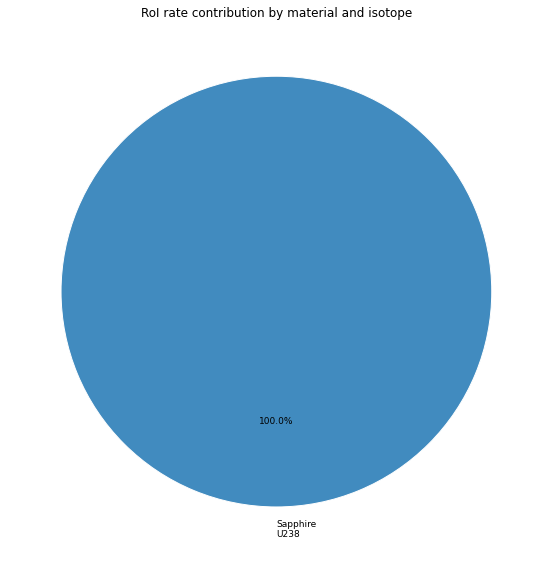

In [19]:
def lighten_color(color, amount=0.5):
    """Blend a color toward white. amount in [0,1], larger = lighter."""
    c = np.array(mcolors.to_rgb(color))
    white = np.array([1, 1, 1])
    return tuple((1 - amount) * c + amount * white)

_qvbbrange = (2350, 2550)

material_isotope_rates = {}   # {material: {isotope: rate}}
material_rates = {}           # {material: total rate}
isotope_rates = {}            # {isotope: total rate}

for isotope, iso_data in estimates.items():
    for material, mat_data in iso_data.items():
        if h_rz_total_var is None:
            h_xy_total_var = mat_data["h_xy_ss_e"].copy()
            h_xy_total_var.reset()
            h_xy_total_var = h_xy_total_var.project(2)

        mat_counts = mat_data["h_rz_ss_e"][
            :bh.loc(fv_r):sum,
            bh.loc(fv_z[0]):bh.loc(fv_z[1]):sum,
            bh.loc(_qvbbrange[0]):bh.loc(_qvbbrange[1])
        ]

        rate = mat_counts.values().sum() * mat_data["scale_factor"]

        # accumulate for plotting
        material_isotope_rates.setdefault(material, {})
        material_isotope_rates[material][isotope] = (
            material_isotope_rates[material].get(isotope, 0.0) + rate
        )

        material_rates[material] = material_rates.get(material, 0.0) + rate
        isotope_rates[isotope] = isotope_rates.get(isotope, 0.0) + rate

# --- plot grouped pie: isotopes grouped by material ------------------------

# sort materials by total contribution, largest first
sorted_materials = sorted(material_rates, key=material_rates.get, reverse=True)

# base colors for materials
base_cmap = plt.get_cmap("tab20")
material_base_colors = {
    mat: base_cmap(2*i % 20) for i, mat in enumerate(sorted_materials)
}

labels = []
sizes = []
colors = []

for material in sorted_materials:
    iso_dict = material_isotope_rates[material]

    # sort isotopes within each material
    sorted_isotopes = sorted(iso_dict, key=iso_dict.get, reverse=True)

    n = len(sorted_isotopes)
    for j, isotope in enumerate(sorted_isotopes):
        rate = iso_dict[isotope]
        if rate <= 0:
            continue

        labels.append(f"{material}\n{isotope}")
        sizes.append(rate)

        # darker to lighter shades within the same material
        shade = 0.15 + 0.65 * (j / max(n - 1, 1))
        colors.append(lighten_color(material_base_colors[material], amount=shade))

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct=lambda p: f"{p:.1f}%" if p > 1 else "",
    startangle=90,
    counterclock=False,
    wedgeprops=dict(edgecolor="white", linewidth=1),
    textprops=dict(fontsize=9),
)

ax.set_title("RoI rate contribution by material and isotope")
plt.tight_layout()
plt.show()

In [20]:
### Xe136 Spectrum
df = pd.read_csv("Xe136_2vbb_summed_spectrum_LXe_normalized.csv")
E_2vbb = df["Esum_keV"]
Rate_2vbb= df["rate_per_tonne_year_keV_natural_LXe"]
Rate_2vbb = df["rate_per_tonne_year_keV_w136eq0p90"]

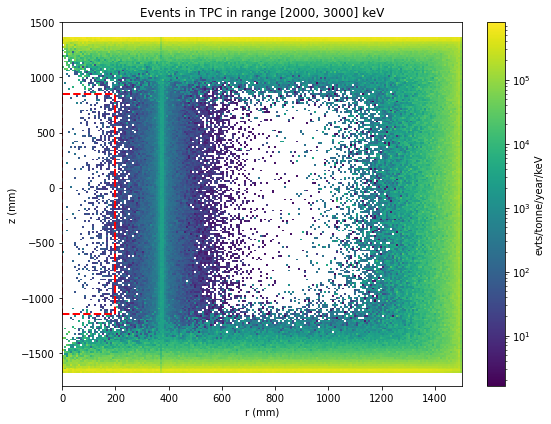

FV considered inside Sapphire: 0.6825870417657958 tonnes


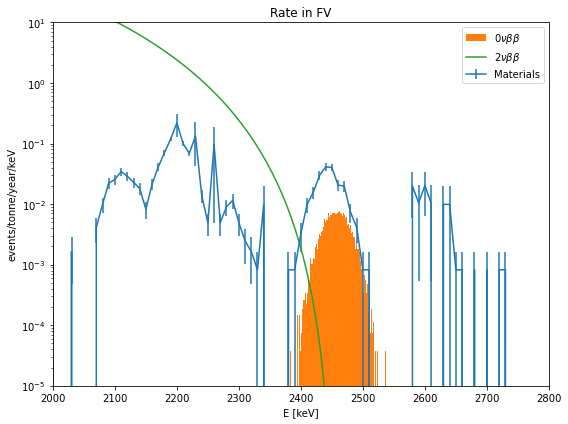

In [21]:
fig, (ax1) = plt.subplots(nrows=1, ncols=1, figsize=(8,6))

pcm1 = ax1.pcolormesh(*h_rz_norm.axes.edges.T, h_rz_norm.values().T, norm=matplotlib.colors.LogNorm())
ax1.add_patch(plt.Rectangle((-0, fv_z[0]), fv_r, fv_z[1]-fv_z[0], color='red', fill=False, linestyle='--', linewidth=2))
ax1.set_title(f"Events in TPC in range [{_erange[0]}, {_erange[1]}] keV")
ax1.set_xlabel("r (mm)")
ax1.set_ylabel("z (mm)")
plt.colorbar(pcm1, label="evts/tonne/year/keV")
plt.colorbar(pcm2, label="evts/tonne/year/keV")
fig.tight_layout()
plt.show()

fig, (ax2) = plt.subplots(nrows=1, ncols=1, figsize=(8,6))

print(f"FV considered inside Sapphire: {fv_mass} tonnes")
h_e_fv = h_rz_total[
    :bh.loc(fv_r):sum,
    bh.loc(fv_z[0]):bh.loc(fv_z[1]):sum,
    :
]
edges = h_e_fv.axes[0].edges
_binwidths = edges[1:]-edges[:-1]
values = (h_e_fv.values())/(fv_mass*_binwidths)
rate_errors = np.sqrt(h_rz_total_var.values())/(fv_mass*_binwidths)


Qvbb_bins = 1000
Qvbb_bin_width = (_erange[1]-_erange[0])/Qvbb_bins 
xe136_expectation = expected_0vbb_events(0.74e28, 1)
xe136_scaling = np.full(len(xe136_sample), xe136_expectation/len(xe136_sample))/Qvbb_bin_width

per2 = ax2.errorbar(edges[:-1], values, yerr = rate_errors, label = 'Materials')

xe136_0vbb = ax2.hist(xe136_sample, weights = xe136_scaling, 
                      bins = np.linspace(*_erange, Qvbb_bins+1), label=r"$0\nu\beta\beta$")

xe136_2vbb = ax2.plot(E_2vbb, Rate_2vbb, label=r"$2\nu\beta\beta$")

ax2.set_title("Rate in FV")
ax2.set_yscale('log')
ax2.set_xlabel("E [keV]")
ax2.set_ylabel("events/tonne/year/keV")
ax2.set_xlim(2000, 2800)
ax2.set_ylim(1e-5, 1e1)
ax2.legend() 

fig.tight_layout()
plt.show()

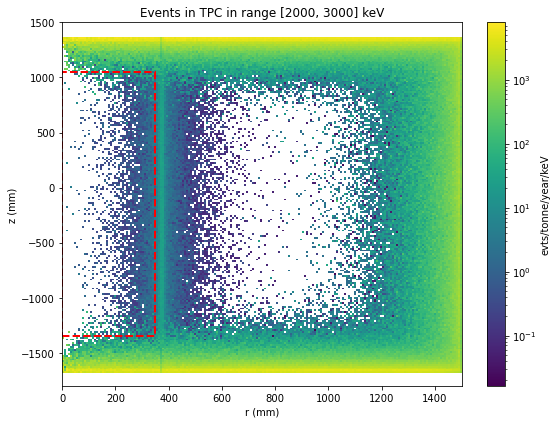

FV considered inside Sapphire: 2.560410731020839 tonnes


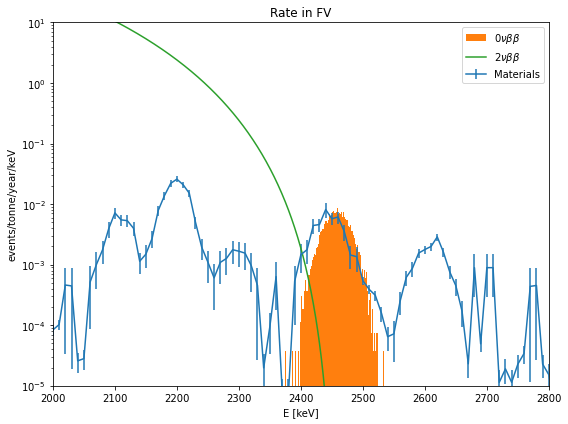

In [22]:
fig, (ax1) = plt.subplots(nrows=1, ncols=1, figsize=(8,6))

pcm1 = ax1.pcolormesh(*h_rz_norm.axes.edges.T, h_rz_norm.values().T, norm=matplotlib.colors.LogNorm())
ax1.add_patch(plt.Rectangle((-0, fv_z[0]), fv_r, fv_z[1]-fv_z[0], color='red', fill=False, linestyle='--', linewidth=2))
ax1.set_title(f"Events in TPC in range [{_erange[0]}, {_erange[1]}] keV")
ax1.set_xlabel("r (mm)")
ax1.set_ylabel("z (mm)")
plt.colorbar(pcm1, label="evts/tonne/year/keV")
plt.colorbar(pcm2, label="evts/tonne/year/keV")
fig.tight_layout()
plt.show()

fig, (ax2) = plt.subplots(nrows=1, ncols=1, figsize=(8,6))

print(f"FV considered inside Sapphire: {fv_mass} tonnes")
h_e_fv = h_rz_total[
    :bh.loc(fv_r):sum,
    bh.loc(fv_z[0]):bh.loc(fv_z[1]):sum,
    :
]
edges = h_e_fv.axes[0].edges
_binwidths = edges[1:]-edges[:-1]
values = (h_e_fv.values())/(fv_mass*_binwidths)
rate_errors = np.sqrt(h_rz_total_var.values())/(fv_mass*_binwidths)


Qvbb_bins = 1000
Qvbb_bin_width = (_erange[1]-_erange[0])/Qvbb_bins 
xe136_expectation = expected_0vbb_events(0.74e28, 1)
xe136_scaling = np.full(len(xe136_sample), xe136_expectation/len(xe136_sample))/Qvbb_bin_width

per2 = ax2.errorbar(edges[:-1], values, yerr = rate_errors, label = 'Materials')

xe136_0vbb = ax2.hist(xe136_sample, weights = xe136_scaling, 
                      bins = np.linspace(*_erange, Qvbb_bins+1), label=r"$0\nu\beta\beta$")

xe136_2vbb = ax2.plot(E_2vbb, Rate_2vbb, label=r"$2\nu\beta\beta$")

ax2.set_title("Rate in FV")
ax2.set_yscale('log')
ax2.set_xlabel("E [keV]")
ax2.set_ylabel("events/tonne/year/keV")
ax2.set_xlim(2000, 2800)
ax2.set_ylim(1e-5, 1e1)
ax2.legend() 

fig.tight_layout()
plt.show()

### Store Templates

In [374]:
import numpy as np
import h5py

# Example contents — replace with your own
bin_edges = h_e_fv.axes[0].edges        # 50 bins -> 51 edges
template_values = (h_e_fv.values())/(fv_mass*_binwidths)     # one value per bin

with h5py.File("../../alea/alea/examples/templates/bkg_template.ii.h5", "w") as f:
    # Create groups
    bins_group = f.create_group("bins")
    templates_group = f.create_group("templates")

    # Create datasets with matching names/paths
    bins_group.create_dataset("0", data=bin_edges)
    templates_group.create_dataset("bkg_template", data=template_values)

print("Created my_template.ii.h5")

Created my_template.ii.h5


In [376]:
xe136_0vbb = np.histogram(xe136_sample, weights = xe136_scaling, 
                      bins = np.linspace(*_erange, Qvbb_bins+1))

In [383]:
import numpy as np
import h5py

# Example contents — replace with your own
bin_edges = xe136_0vbb[1]        # 50 bins -> 51 edges
template_values = xe136_0vbb[0]     # one value per bin

with h5py.File("../../alea/alea/examples/templates/0vbb_template.ii.h5", "w") as f:
    # Create groups
    bins_group = f.create_group("bins")
    templates_group = f.create_group("templates")

    # Create datasets with matching names/paths
    bins_group.create_dataset("0", data=bin_edges)
    templates_group.create_dataset("xe136_0vbb_template", data=template_values)

print("Created my_template.ii.h5")

Created my_template.ii.h5
